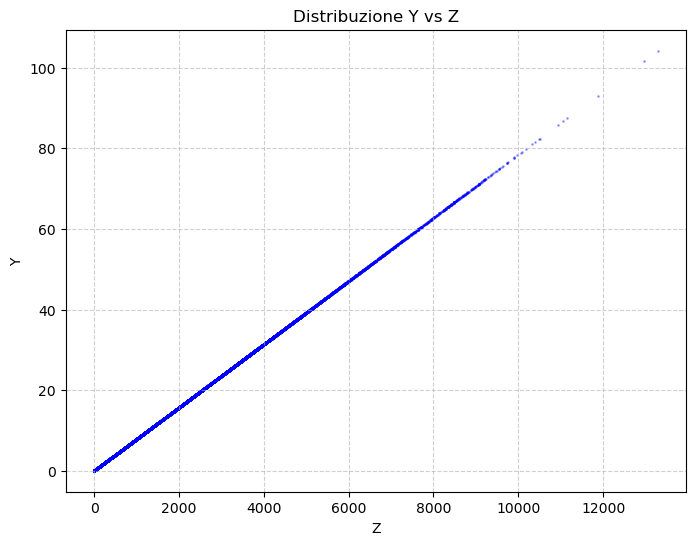

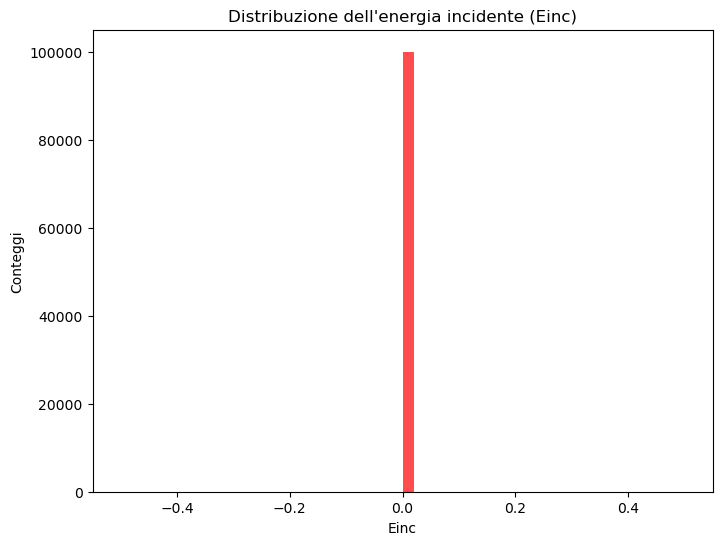

In [5]:
import uproot
import matplotlib.pyplot as plt

# 1. Apri il file e seleziona il TTree
file = uproot.open("build/yz.root")
tree = file["yz;1"]

# 2. Estrai le variabili di interesse in un DataFrame
# Scegliamo ad esempio 'y' e 'z' per vedere la distribuzione spaziale
branches = ["y", "z"]
df = tree.arrays(branches, library="pd")

# 3. Plot: Scatter plot di y vs z
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['y'], alpha=0.3, s=1, color='blue')
plt.title("Distribuzione Y vs Z")
plt.xlabel("Z")
plt.ylabel("Y")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Esempio di istogramma per la variabile 'Einc'
plt.figure(figsize=(8, 6))
plt.hist(tree["Einc"].array(library="np"), bins=50, color='red', alpha=0.7)
plt.title("Distribuzione dell'energia incidente (Einc)")
plt.xlabel("Einc")
plt.ylabel("Conteggi")
plt.show()

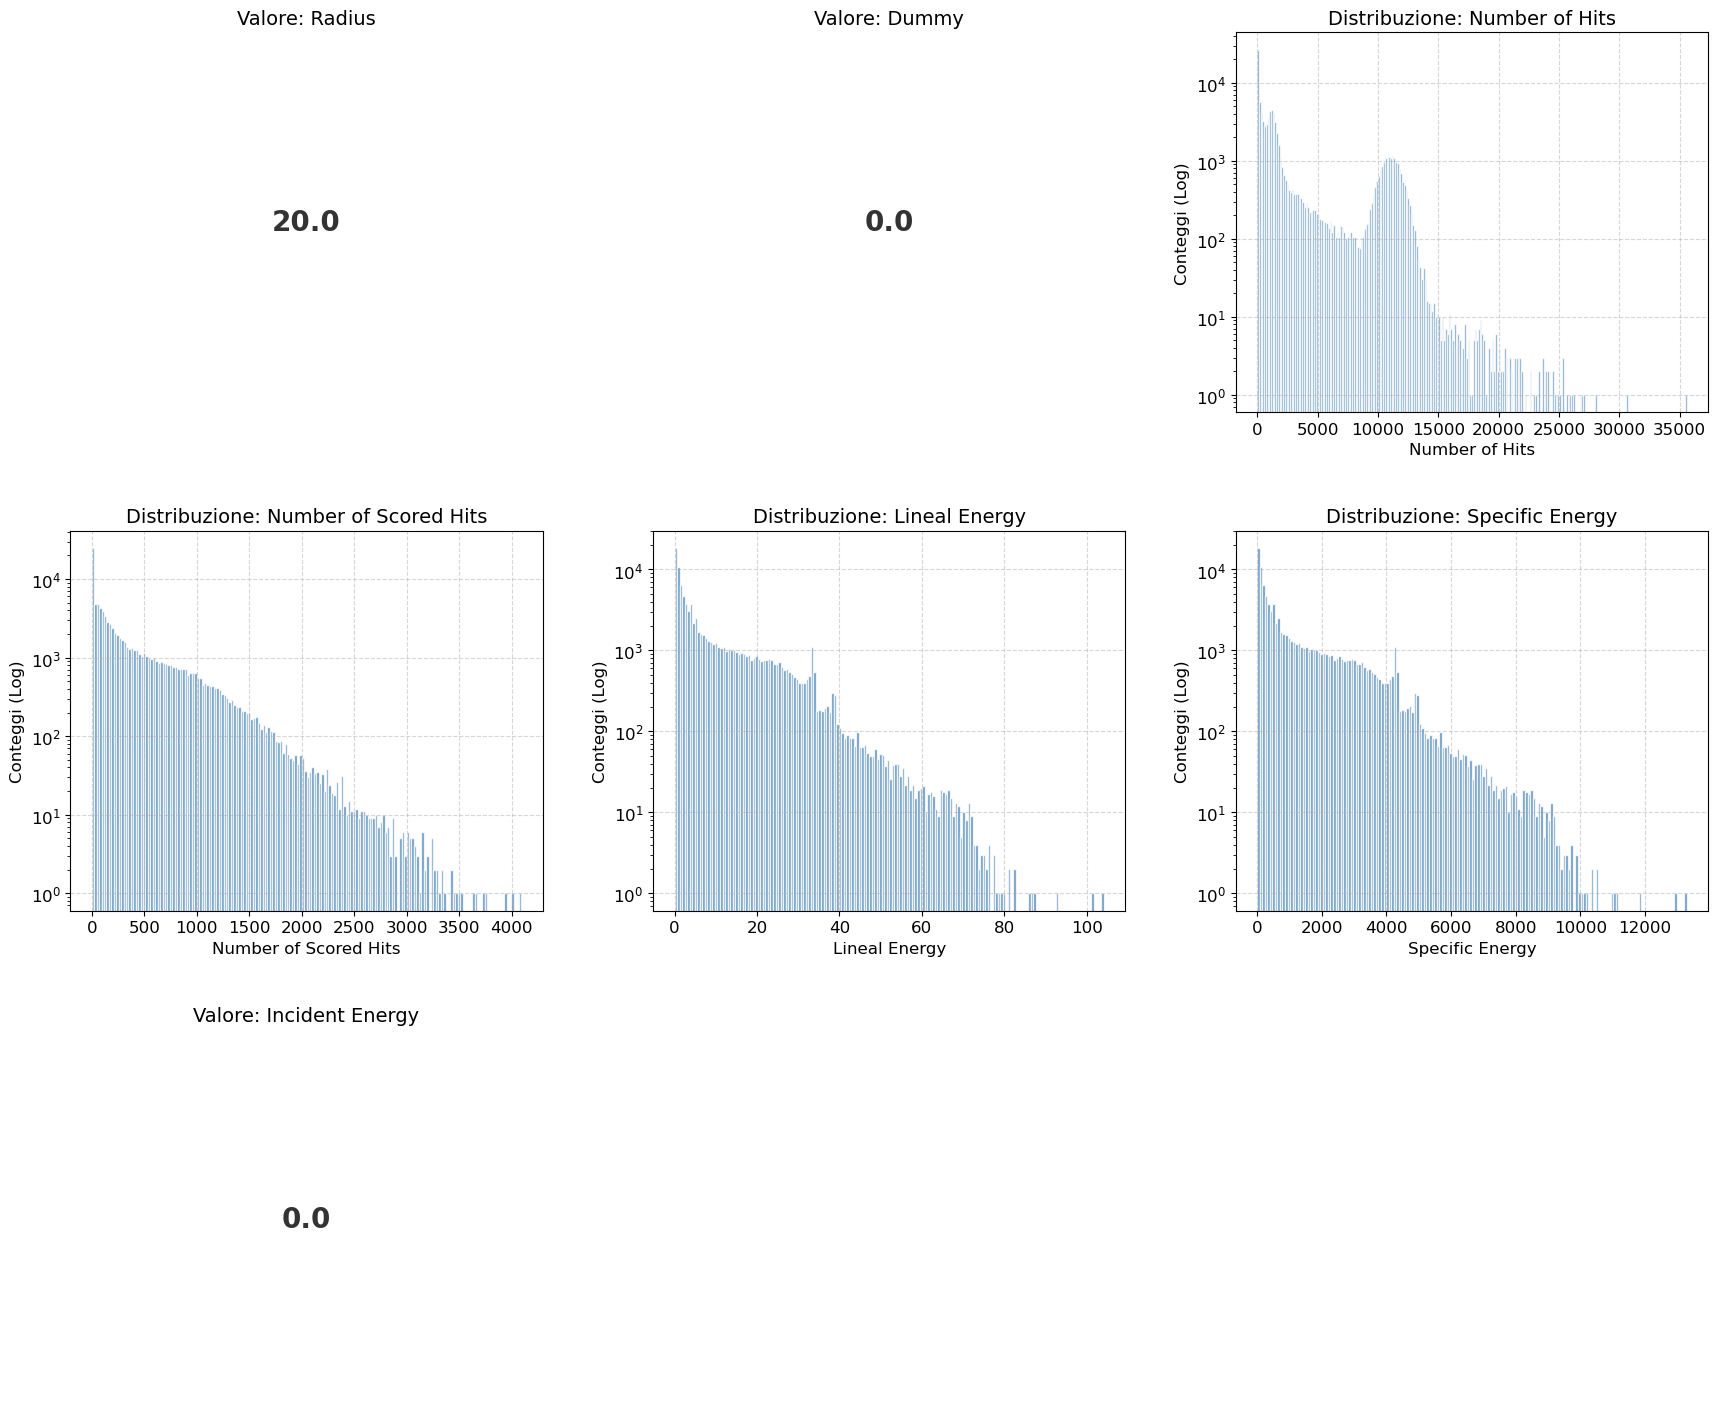

In [ ]:
import uproot
import matplotlib.pyplot as plt
import numpy as np

# --- Configurazione Stile ---
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "grid.alpha": 0.5,
    "grid.linestyle": "--"
})

# 1. Caricamento dati
file = uproot.open("build/yz.root")
tree = file["yz;1"]
branch_names = tree.keys()

# Mappatura nomi: aggiungi qui altre chiavi se necessario
custom_names = {
    'y': 'Lineal Energy',
    'z': 'Specific Energy',
    'nbHits': 'Number of Hits',
    'nbScoredHits': 'Number of Scored Hits',
    'Einc': 'Incident Energy',
    'radius': 'Radius',
    'dummy': 'Dummy'
}

# 2. Setup Layout
n = len(branch_names)
cols = 3
rows = (n + 2) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

color_main = '#4682B4' 

for i, branch_name in enumerate(branch_names):
    data = tree[branch_name].array(library="np")
    ax = axes[i]
    
    # Recupera il nome personalizzato, altrimenti usa quello di default formattato
    clean_name = custom_names.get(branch_name, branch_name.replace("_", " ").capitalize())
    
    # Controllo: è costante?
    if np.all(data == data[0]):
        ax.text(0.5, 0.5, f"{data[0]}", 
                horizontalalignment='center', verticalalignment='center',
                fontsize=20, fontweight='bold', color='#333333', transform=ax.transAxes)
        ax.set_title(f"Valore: {clean_name}")
        ax.axis('off')
    else:
        # Istogramma
        ax.hist(data, bins='auto', color=color_main, edgecolor='white', alpha=0.8)
        ax.set_title(f"Distribuzione: {clean_name}")
        ax.set_xlabel(clean_name) # Asse X con il nome nuovo
        ax.set_ylabel("Conteggi")
        ax.grid(True)
        
        # Logica Scala Logaritmica
        data_positive = data[data > 0]
        if len(data_positive) > 0 and (np.max(data) / (np.min(data_positive) + 1e-9) > 100):
            ax.set_yscale('log')
            ax.set_ylabel("Conteggi (Log)")

# Rimuovi subplot vuoti
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0)
plt.show()

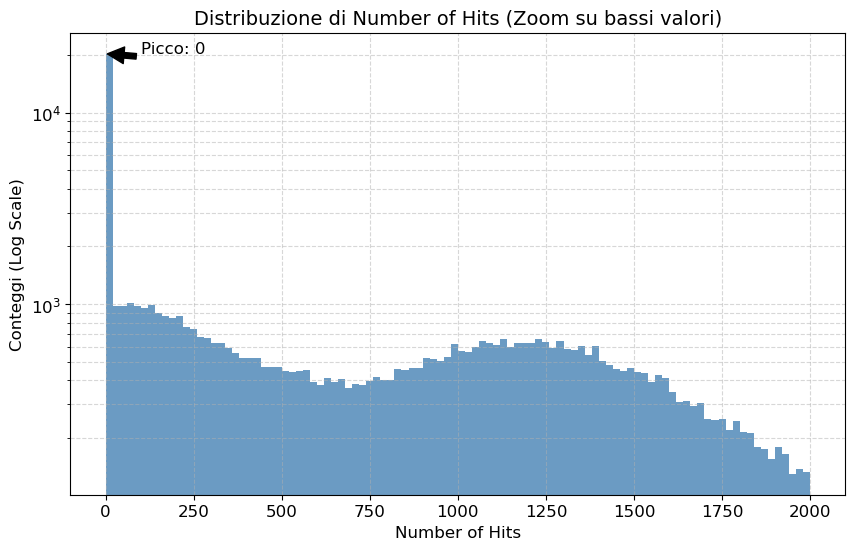

In [10]:
import uproot
import matplotlib.pyplot as plt
import numpy as np

# 1. Caricamento dati
file = uproot.open("build/yz.root")
tree = file["yz;1"]
data = tree["nbHits"].array(library="np")

# 2. Configurazione Plot
plt.figure(figsize=(10, 6))

# Usiamo un numero elevato di bin (es. 100) per vedere meglio la struttura vicino allo zero
# log=True abilita la scala logaritmica sull'asse Y direttamente
counts, bins, patches = plt.hist(data, bins=100, range=(0, 2000), 
                                 color='#4682B4', edgecolor='none', alpha=0.8, log=True)

plt.title("Distribuzione di Number of Hits (Zoom su bassi valori)")
plt.xlabel("Number of Hits")
plt.ylabel("Conteggi (Log Scale)")
plt.grid(True, which="both", linestyle='--', alpha=0.5)

# Aggiungiamo una annotazione se c'è un picco importante vicino allo zero
max_bin_index = np.argmax(counts)
plt.annotate(f'Picco: {bins[max_bin_index]:.0f}', 
             xy=(bins[max_bin_index], counts[max_bin_index]), 
             xytext=(bins[max_bin_index] + 100, counts[max_bin_index]),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

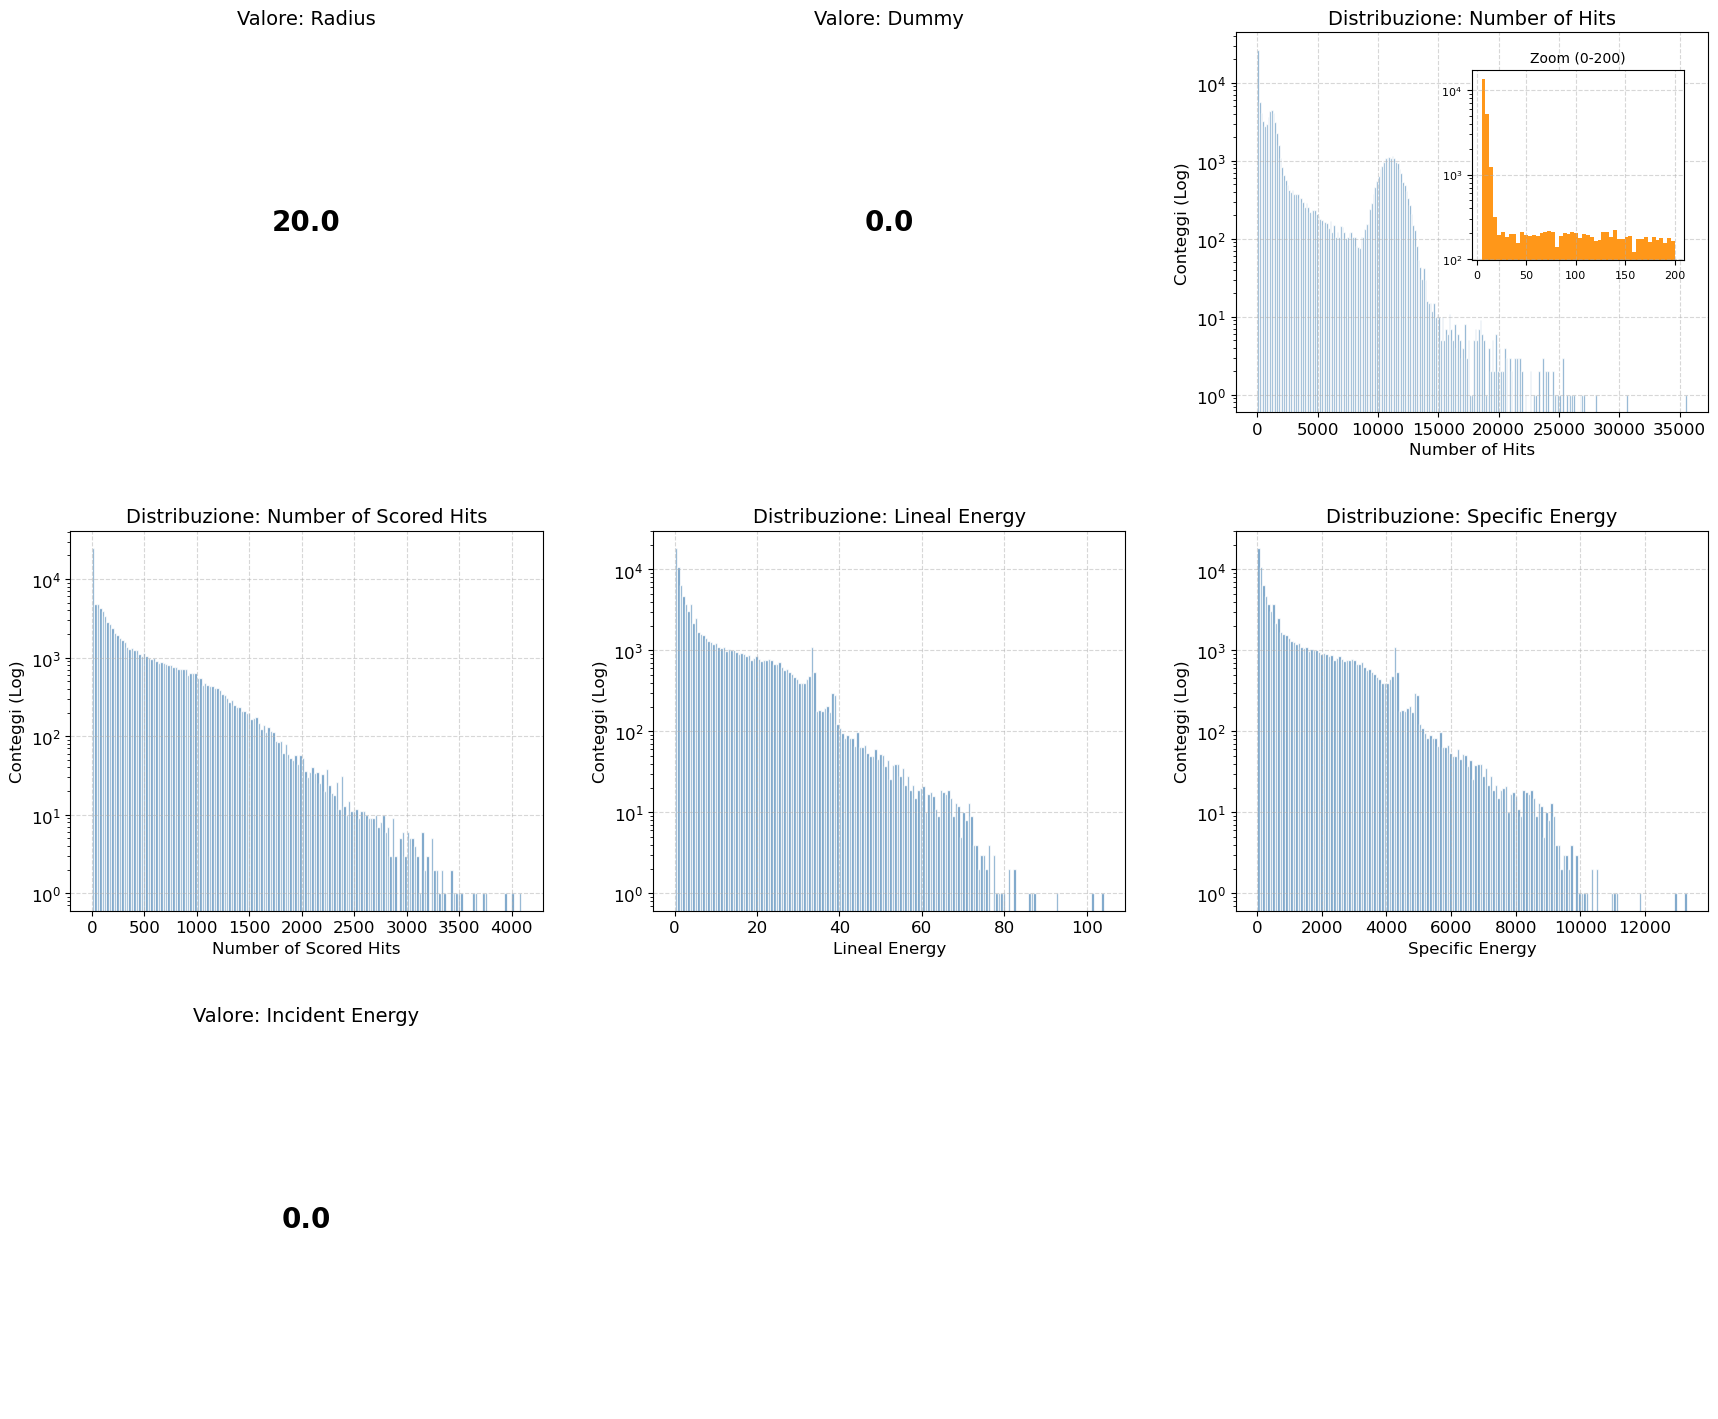

In [11]:
import uproot
import matplotlib.pyplot as plt
import numpy as np

# Configurazione Stile
plt.rcParams.update({"font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12, "grid.alpha": 0.5})

file = uproot.open("build/yz.root")
tree = file["yz;1"]
branch_names = tree.keys()

custom_names = {
    'y': 'Lineal Energy',
    'z': 'Specific Energy',
    'nbHits': 'Number of Hits',
    'nbScoredHits': 'Number of Scored Hits',
    'Einc': 'Incident Energy',
    'radius': 'Radius',
    'dummy': 'Dummy'
}

n = len(branch_names)
cols = 3
rows = (n + 2) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()
color_main = '#4682B4'

for i, branch_name in enumerate(branch_names):
    data = tree[branch_name].array(library="np")
    ax = axes[i]
    clean_name = custom_names.get(branch_name, branch_name.replace("_", " ").capitalize())
    
    if np.all(data == data[0]):
        ax.text(0.5, 0.5, f"{data[0]}", ha='center', va='center', fontsize=20, fontweight='bold', transform=ax.transAxes)
        ax.set_title(f"Valore: {clean_name}")
        ax.axis('off')
    else:
        # Plot principale
        ax.hist(data, bins='auto', color=color_main, edgecolor='white', alpha=0.8)
        ax.set_title(f"Distribuzione: {clean_name}")
        ax.set_xlabel(clean_name)
        ax.set_ylabel("Conteggi")
        ax.grid(True)
        
        # Log scale automatica
        data_positive = data[data > 0]
        if len(data_positive) > 0 and (np.max(data) / (np.min(data_positive) + 1e-9) > 100):
            ax.set_yscale('log')
            ax.set_ylabel("Conteggi (Log)")
            
        # --- LOGICA INSET PER NB HITS ---
        if branch_name == 'nbHits':
            # Crea un inset: [x, y, larghezza, altezza] in coordinate normalizzate 0-1
            # Questo posiziona lo zoom in alto a destra
            ax_inset = ax.inset_axes([0.5, 0.4, 0.45, 0.5]) 
            
            # Zoom sui primi 200 valori
            zoom_data = data[(data >= 0) & (data <= 200)]
            ax_inset.hist(zoom_data, bins=50, color='darkorange', alpha=0.9, log=True)
            
            ax_inset.set_title("Zoom (0-200)", fontsize=10)
            ax_inset.grid(True, linestyle='--', alpha=0.5)
            ax_inset.tick_params(axis='both', which='major', labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0)
plt.show()

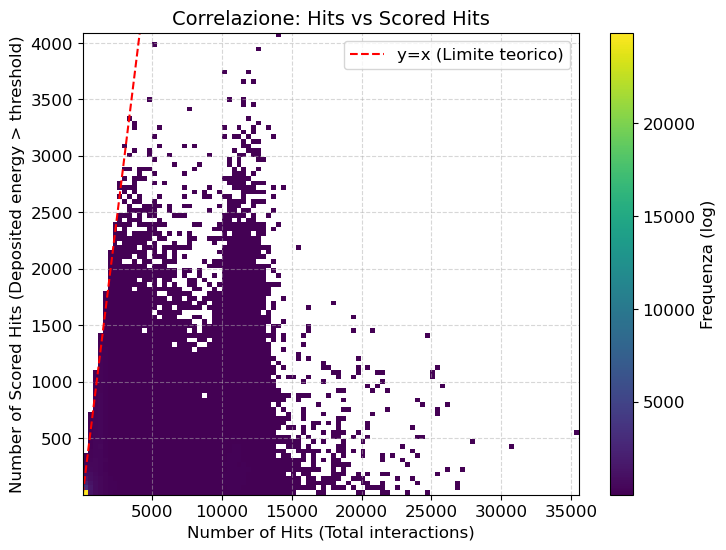

In [12]:
import uproot
import matplotlib.pyplot as plt

# 1. Carica i dati
file = uproot.open("build/yz.root")
tree = file["yz;1"]
df = tree.arrays(["nbHits", "nbScoredHits"], library="pd")

# 2. Crea un grafico 2D (istogramma di densità)
plt.figure(figsize=(8, 6))
plt.hist2d(df['nbHits'], df['nbScoredHits'], bins=(100, 100), cmap='viridis', cmin=1)

plt.colorbar(label='Frequenza (log)')
plt.title("Correlazione: Hits vs Scored Hits")
plt.xlabel("Number of Hits (Total interactions)")
plt.ylabel("Number of Scored Hits (Deposited energy > threshold)")
plt.grid(True, linestyle='--', alpha=0.5)

# Aggiungiamo una linea di riferimento y=x
max_val = max(df['nbHits'].max(), df['nbScoredHits'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='y=x (Limite teorico)')
plt.legend()

plt.show()

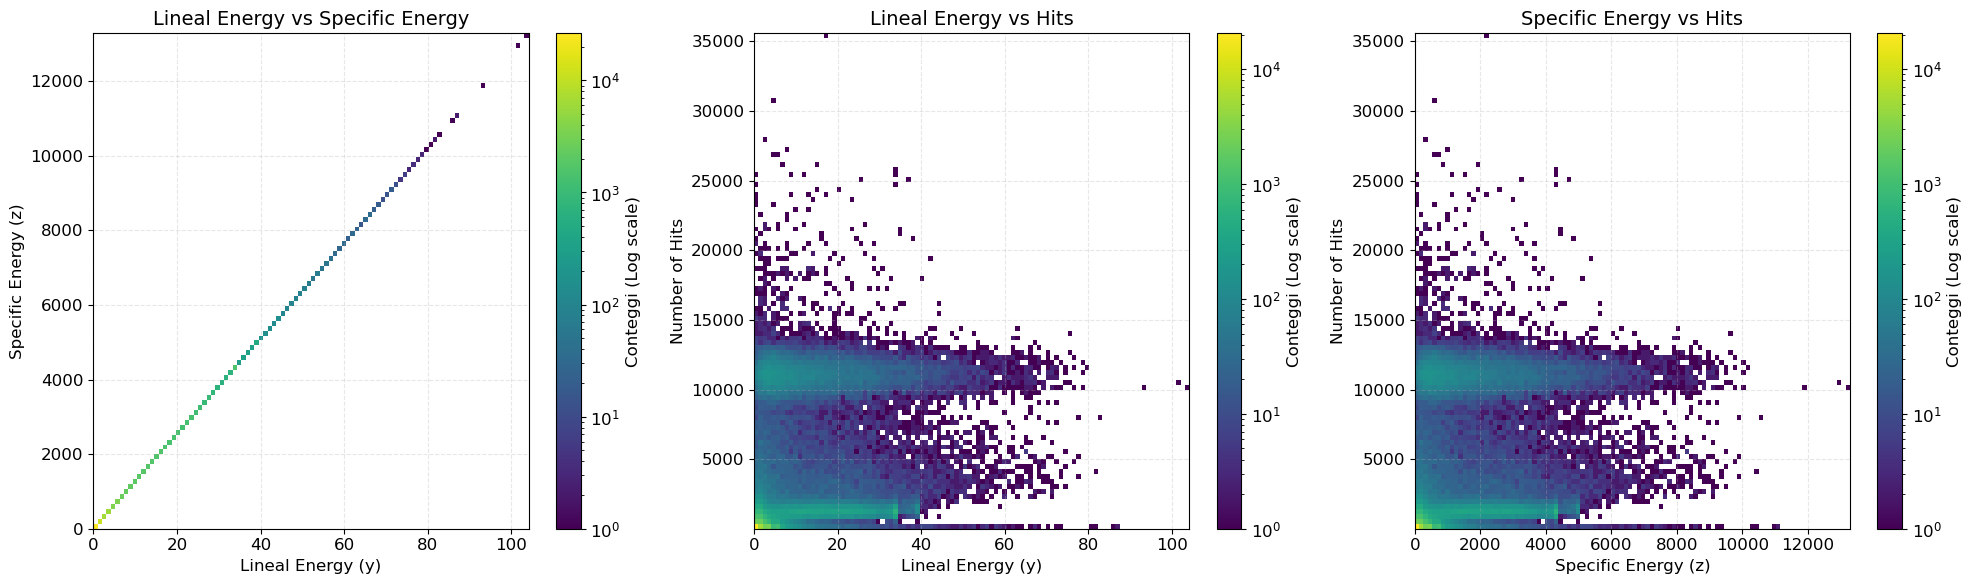

In [14]:
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. Carica i dati
file = uproot.open("build/yz.root")
tree = file["yz;1"]
df = tree.arrays(["y", "z", "nbHits"], library="pd")

# 2. Setup Figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Liste per le configurazioni dei grafici (colonna_x, colonna_y, titolo, label_x, label_y)
plots_config = [
    ('y', 'z', 'Lineal Energy vs Specific Energy', 'Lineal Energy (y)', 'Specific Energy (z)'),
    ('y', 'nbHits', 'Lineal Energy vs Hits', 'Lineal Energy (y)', 'Number of Hits'),
    ('z', 'nbHits', 'Specific Energy vs Hits', 'Specific Energy (z)', 'Number of Hits')
]

# 3. Generazione delle heatmap
for ax, (x_col, y_col, title, x_lab, y_lab) in zip(axes, plots_config):
    # hist2d crea la heatmap. 
    # norm=LogNorm() è fondamentale per vedere la struttura su scala logaritmica
    h = ax.hist2d(df[x_col], df[y_col], bins=100, norm=LogNorm(), cmap='viridis')
    
    ax.set_title(title)
    ax.set_xlabel(x_lab)
    ax.set_ylabel(y_lab)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Aggiungi colorbar
    fig.colorbar(h[3], ax=ax, label='Conteggi (Log scale)')

plt.tight_layout()
plt.show()

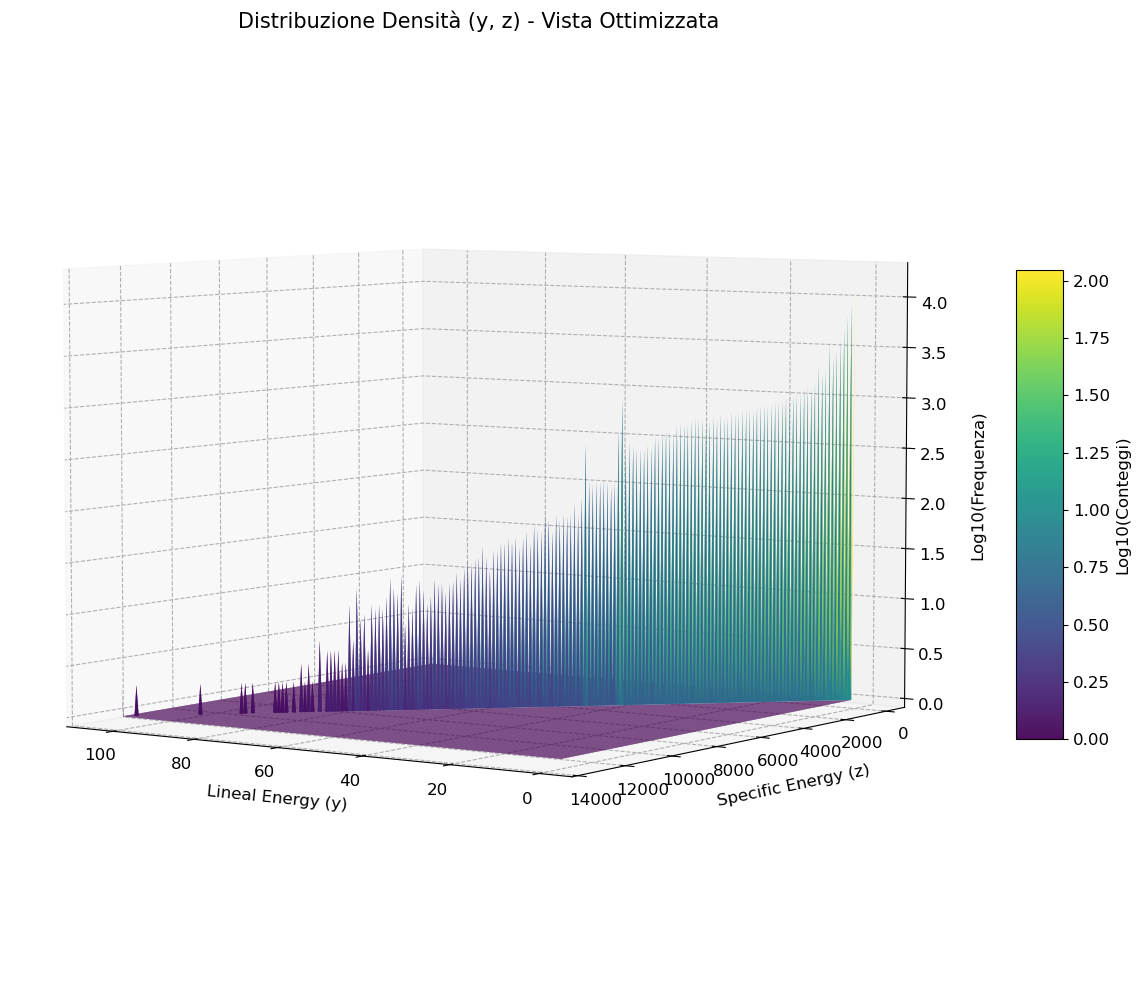

In [ ]:
import uproot
import matplotlib.pyplot as plt
import numpy as np

# 1. Carica dati
file = uproot.open("build/yz.root")
tree = file["yz;1"]
y = tree["y"].array(library="np")
z = tree["z"].array(library="np")

# 2. Aumentiamo la risoluzione
bins_n = 200
hist, xedges, yedges = np.histogram2d(y, z, bins=bins_n)

# 3. Setup Mesh per il plot
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)

# Trasformazione logaritmica (fondamentale per la visibilità)
Z = np.log10(hist.T + 1) 

# 4. Plot 3D Ottimizzato
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 'shade=True' e 'antialiased=True' eliminano l'effetto "a gradini"
# 'rstride' e 'cstride' controllano la densità della mesh (1 è il massimo dettaglio)
surf = ax.plot_surface(X, Y, Z, cmap='viridis', shade=True, 
                       antialiased=True, rstride=1, cstride=1, alpha=0.95)

# Aggiustamenti estetici
ax.set_title("Distribuzione Densità (y, z) - Vista Ottimizzata", fontsize=15)
ax.set_xlabel("Lineal Energy (y)", labelpad=10)
ax.set_ylabel("Specific Energy (z)", labelpad=10)
ax.set_zlabel("Log10(Frequenza)", labelpad=10)

# Angolazione: guardiamo la diagonale di profilo
ax.view_init(elev=5, azim=125)

# Pulizia sfondo
ax.grid(True) # Rimuove le griglie invasive
ax.set_facecolor('white')

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Log10(Conteggi)')

plt.tight_layout()
plt.show()

In [29]:
import uproot
import numpy as np
import plotly.graph_objects as go

# 1. Caricamento dati (identico alla tua versione)
file = uproot.open("build/yz.root")
tree = file["yz;1"]
y = tree["y"].array(library="np")
z = tree["z"].array(library="np")

# 2. Istogramma 2D (Aumentiamo binnaggio a 100)
bins_n = 100
hist, xedges, yedges = np.histogram2d(y, z, bins=bins_n)

# 3. Preparazione per la Surface
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
Z = np.log10(hist.T + 1)  # Log scale come nella tua versione

# 4. Creazione del plot interattivo con Plotly
fig = go.Figure(data=[go.Surface(
    z=Z, 
    x=x_centers, 
    y=y_centers, 
    colorscale='Plasma',
    colorbar=dict(title='Log10(Conteggi)')
)])

# 5. Aggiustamenti Layout
fig.update_layout(
    title='Distribuzione Densità (y, z) - Interattiva',
    scene=dict(
        xaxis_title='Lineal Energy (y)',
        yaxis_title='Specific Energy (z)',
        zaxis_title='Log10(Frequenza)',
        # Imposta la vista iniziale (opzionale)
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=0.8)
        )
    ),
    autosize=True,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()